# Exercise 1

A mean: 1.9258204186597894
A variance: 2.160135275141264
B mean: 2.1649914718259233
B variance: 2.062411318558675
C mean: 2.098032658754571
C variance: 1.60109337248933


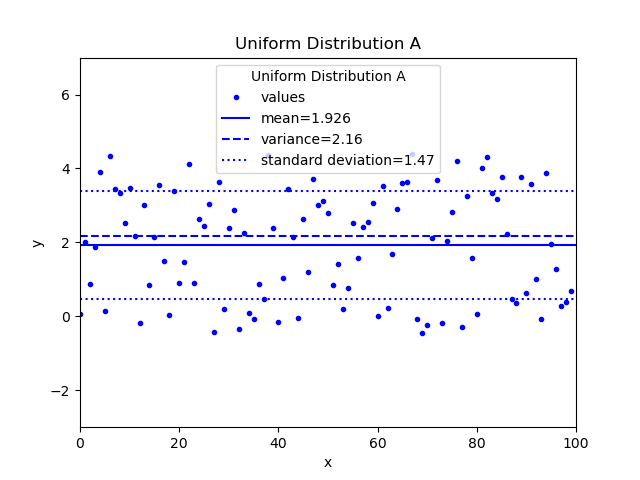

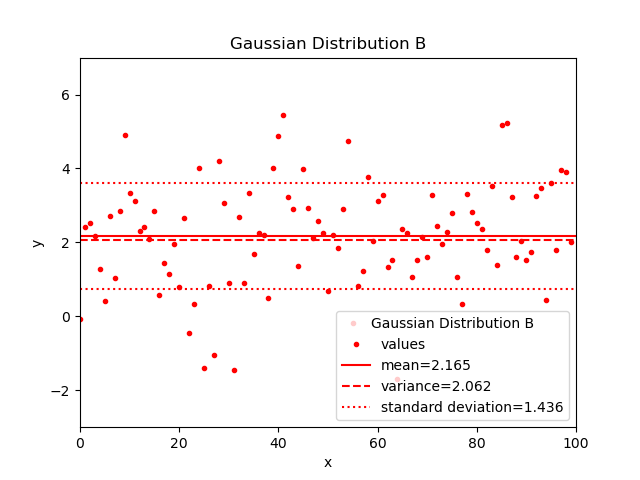

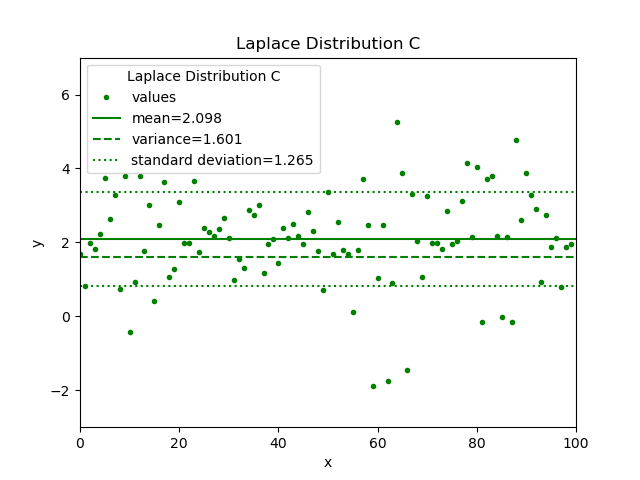

In [29]:
%matplotlib widget

#import mpld3
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import math
from math import e, sqrt, pow, pi
import scipy
from IPython.display import display, Markdown, Latex
from scipy import stats
plt.style.use('default')
plt.interactive(True)


def GenSequenceUniform(n:int, mean:float, variance:float):
    b = mean + math.sqrt(3)*math.sqrt(variance)
    a = mean - math.sqrt(3)*math.sqrt(variance)
    seq = np.random.uniform(a, b, n)
    return seq
def GenSequenceGauss(n, mean, variance):
    return np.random.normal(mean, math.sqrt(variance), n)
def GenSequenceLaplace(n, mean, variance):
    return np.random.laplace(mean, math.sqrt(0.5*variance), n)
def GenSequenceCauchy(n, a, b):
    return stats.cauchy.rvs(a, b, n)

meanABC = 2
varianceABC = 2
nABC = 100

def GenSequencesABCD(n, mean, variance, caucha=2, cauchb=1):
    seqA = GenSequenceUniform(n, mean, variance)
    seqB = GenSequenceGauss(n, mean, variance)
    seqC = GenSequenceLaplace(n, mean, variance)
    seqD = GenSequenceCauchy(n, caucha, cauchb)

    return seqA, seqB, seqC, seqD 
    
seqA, seqB, seqC, seqD = GenSequencesABCD(nABC, meanABC, varianceABC)

print("A mean: " + str(np.mean(seqA)))
print("A variance: " + str(np.var(seqA)))

print("B mean: " + str(np.mean(seqB)))
print("B variance: " + str(np.var(seqB)))

print("C mean: " + str(np.mean(seqC)))
print("C variance: " + str(np.var(seqC)))

def DrawSequenceMeanVariance(seq, name, color, ymn:float|None=-3.0, ymx:float|None=7.0, mark = "."):
    fig = plt.figure()
    plt.interactive(True)
    plt.axis((0, len(seq), ymn, ymx))
    plt.xlabel("x")
    plt.ylabel("y")
    mean = np.mean(seq)
    var = np.var(seq)
    devh = mean + math.sqrt(var)
    devl = mean - math.sqrt(var)
    plt.plot(seq, color + mark, label="values");
    plt.axhline(mean, color = color, linestyle = "-",
                label="mean=" + str(round(mean, 3)))
    plt.axhline(np.var(seq), color = color, linestyle = "--",
                label="variance=" + str(round(var, 3)))
    plt.axhline(devh, color = color, linestyle = ":", label="standard deviation=" + str(round(math.sqrt(var), 3)))
    plt.axhline(devl, color = color, linestyle = ":")
    plt.title(name)
    plt.legend(title=name)
    plt.show(block=True)
    
DrawSequenceMeanVariance(seqA, "Uniform Distribution A", "b")
DrawSequenceMeanVariance(seqB, "Gaussian Distribution B", "r")
DrawSequenceMeanVariance(seqC, "Laplace Distribution C", "g")


# Exercise 2

D mean: 2.109428724218856
D variance: 2.279285260252521


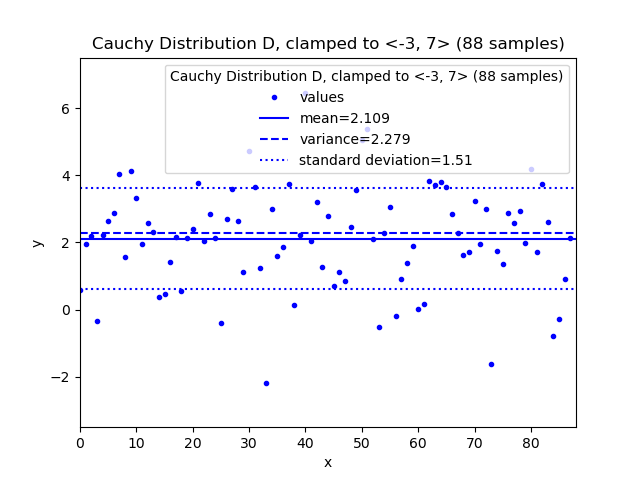

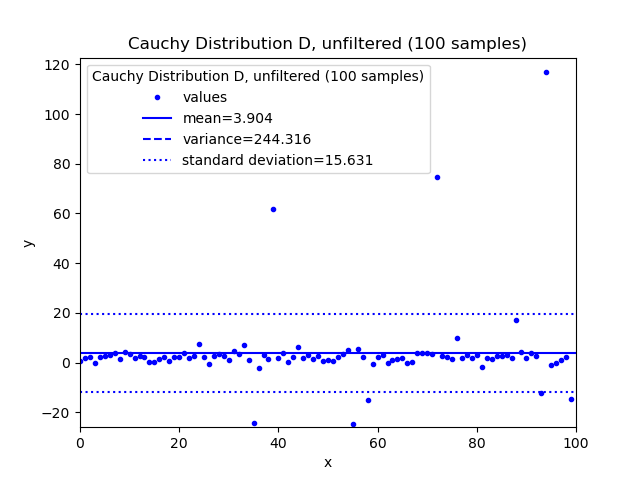

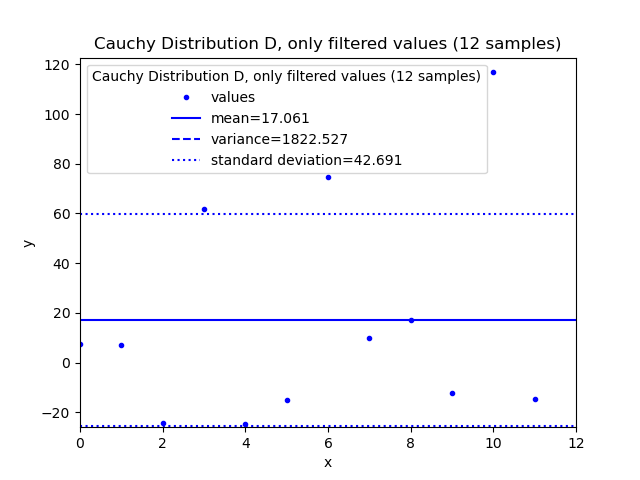

In [2]:
seqDremoved = []
seqDfiltered = []
for x in seqD:
    if -3 <= x <= 7:
        seqDfiltered.append(x)
    else:
        seqDremoved.append(x)
print("D mean: " + str(np.mean(seqDfiltered)))
print("D variance: " + str(np.var(seqDfiltered)))
DrawSequenceMeanVariance(seqDfiltered, "Cauchy Distribution D, clamped to <-3, 7> (" + str(len(seqDfiltered)) + " samples)", "b", -3.5, 7.5)
DrawSequenceMeanVariance(seqD, "Cauchy Distribution D, unfiltered (" + str(len(seqD)) + " samples)", "b", min(seqD) * 1.05, max(seqD) * 1.05)
DrawSequenceMeanVariance(seqDremoved, "Cauchy Distribution D, only filtered values (" + str(len(seqDremoved)) + " samples)", "b", min(seqDremoved) * 1.05, max(seqDremoved) * 1.05)


## Notes:
The distribution tends to generate a number of relatively extreme values that greatly affect its variance, though with little effect on the mean.

# Exercise 3

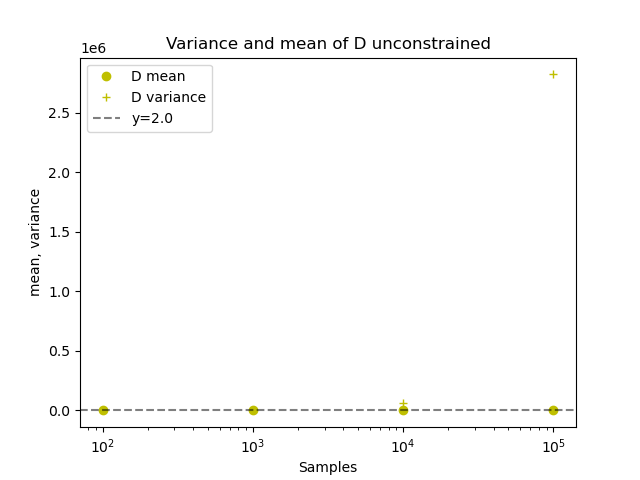

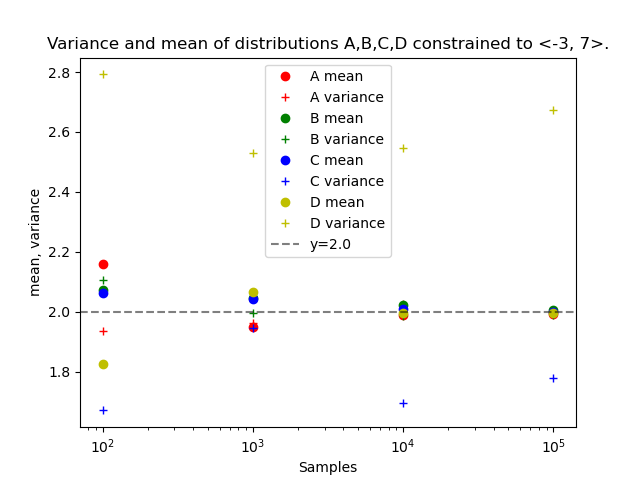

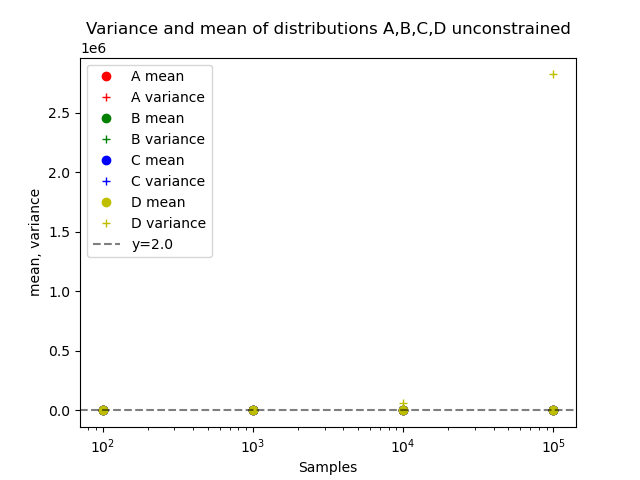

In [3]:
ns = [100, 1000, 10000, 100000]
resultsmean = [[], [], [], []]
resultsmeannofilter = [[], [], [], []]
resultsvar = [[], [], [], []]
resultsvarnofilter = [[], [], [], []]

for n in ns:
    seqs = list(GenSequencesABCD(n, meanABC, varianceABC))
    i = 0
    for seq in seqs:
        resultsmeannofilter[i].append(np.mean(seq))
        resultsvarnofilter[i].append(np.var(seq))
        nseq = [x for x in seq if (-3 <= x <= 7)]
        resultsmean[i].append(np.mean(nseq))
        resultsvar[i].append(np.var(nseq))
        i+=1
distnames = ["A", "B", "C", "D"]
distcolors = ["r", "g", "b", "y"]


fig = plt.figure()
plt.title("Variance and mean of distributions A,B,C,D constrained to <-3, 7>.")
plt.xlabel("Samples")
plt.ylabel("mean, variance")
plt.xscale('log')
for i in range(0, 4):
    plt.plot(ns, resultsmean[i], distcolors[i] + "o", label=distnames[i] + " mean")
    plt.plot(ns, resultsvar[i], distcolors[i] + "+", label=distnames[i] + " variance")
    #print(distnames[i], str(resultsmean[i]), str(resultsvar[i]))
plt.axhline(2, color = 'k', linestyle = "--", label="y=2.0", alpha=0.5)
plt.legend()

fig = plt.figure()
plt.title("Variance and mean of distributions A,B,C,D unconstrained")
plt.xlabel("Samples")
plt.ylabel("mean, variance")
plt.xscale('log')
for i in range(0, 4):
    plt.plot(ns, resultsmeannofilter[i], distcolors[i] + "o", label=distnames[i] + " mean")
    plt.plot(ns, resultsvarnofilter[i], distcolors[i] + "+", label=distnames[i] + " variance")
plt.axhline(2, color = 'k', linestyle = "--", label="y=2.0", alpha=0.5)
plt.legend()

fig = plt.figure()
plt.title("Variance and mean of D unconstrained")
plt.xlabel("Samples")
plt.ylabel("mean, variance")
plt.xscale('log')
i = 3
plt.plot(ns, resultsmeannofilter[i], distcolors[i] + "o", label=distnames[i] + " mean")
plt.plot(ns, resultsvarnofilter[i], distcolors[i] + "+", label=distnames[i] + " variance")
plt.axhline(2, color = 'k', linestyle = "--", label="y=2.0", alpha=0.5)
plt.legend()
plt.show()

#fig = plt.figure()
#plt.xlabel("Samples")
#plt.ylabel("mean, variance")
#plt.xscale('log')
#i = 3
#plt.plot(ns, resultsmean[i], distcolors[i] + "o", label=distnames[i] + " mean")
#plt.plot(ns, resultsvar[i], distcolors[i] + "+", label=distnames[i] + " variance")
#plt.axhline(2, color = 'k', linestyle = "--", label="y=2.0", alpha=0.5)
#plt.legend()

## Notes:

As expected, both the variance and the mean tend towards the intended value, though the Cautchy distribution's (D) variance tends to diverge quite a lot, desplite the results being constrained to <-3, 7>

# Exercise 4

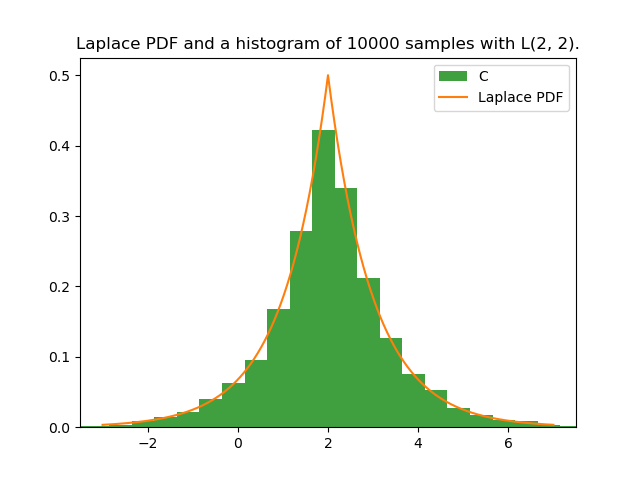

/opt/conda/lib/python3.13/site-packages/ipympl/backend_nbagg.py:392: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  self.figure.savefig(buf, format='png', dpi='figure')


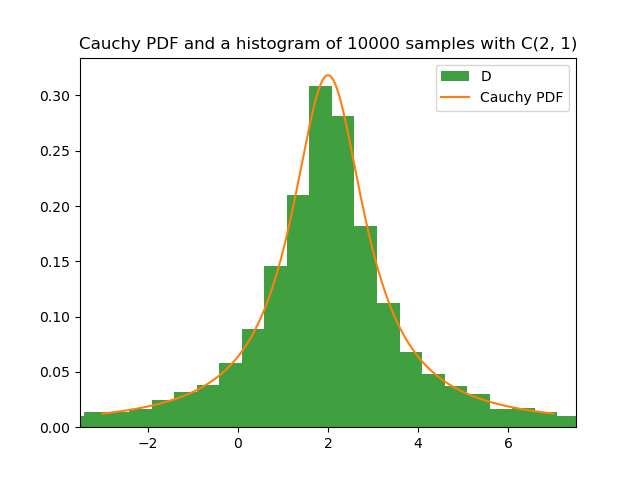

In [4]:
nsamples = 10000

seqA, seqB, seqC, seqD = GenSequencesABCD(nsamples, meanABC, varianceABC)

def ComputeDistribution(npoints, mn, mx, f, a, b):
    ret = []
    points = []
    for i in range(0, npoints):
        p = ((i/npoints) * (mx-mn))+mn
        points.append(p)
        ret.append(f(p, a, b))
    return ret, points
def HistogramCompare(seq, binwidth, points, dist, histlabel, plotlabel, title, axis = (None, None, None, None), color='g', alpha=0.75, show=True):
    fig = plt.figure()
    plt.title(title)
    plt.axis((min(seq) if axis[0] is None else axis[0], max(seq) if axis[1] is None else axis[1], axis[2], axis[3]))
    plt.hist(seq, bins=np.arange(min(seq), max(seq) + binwidth, binwidth), density=True, facecolor=color, alpha=alpha, label=histlabel)
    if points is not None:
        plt.plot(points, dist, label=plotlabel)
    plt.legend()
    if show:
        plt.show()
def Histogram(seq, binwidth, title, axis = (None, None, None, None), color='g', alpha=0.75, show=True):
    fig = plt.figure()
    plt.title(title)
    plt.axis((min(seq) if axis[0] is None else axis[0], max(seq) if axis[1] is None else axis[1], axis[2], axis[3]))
    plt.hist(seq, bins=np.arange(min(seq), max(seq) + binwidth, binwidth), density=True, facecolor=color, alpha=alpha)
    if show:
        plt.show()
laplace = lambda x, a, b: (1/(2*b))*(math.e**-(abs(x-a)/b))
cauchy = lambda x, a, b:  (b/math.pi)/(b**2 + (x-a)**2)

distC, pointsC = ComputeDistribution(nsamples, -3, 7, laplace, meanABC, math.sqrt(0.5*varianceABC)) 
distD, pointsD = ComputeDistribution(nsamples, -3, 7, cauchy, 2, 1) 

#print(distC)

#fig = plt.figure()
#plt.title(f"Laplace PDF and a histogram of {len(seqC)} samples with L(2, 2).")
#plt.axis((-3.5, 7.5, None, None))
#n, bins, patches = plt.hist(seqC, bins=np.arange(min(seqC), max(seqC) + 0.5, 0.5), density=True, facecolor='g', alpha=0.75, label="C")
#plt.plot(pointsC, distC, label="laplace PDF")
#plt.legend()

HistogramCompare(seqC, 0.5, pointsC, distC, "C", "Laplace PDF", f"Laplace PDF and a histogram of {len(seqC)} samples with L(2, 2)."\
     , axis = (-3.5, 7.5, None, None))

HistogramCompare(seqD, 0.5, pointsD, distD, "D", "Cauchy PDF", f"Cauchy PDF and a histogram of {len(seqD)} samples with C(2, 1)", axis = (-3.5, 7.5, None, None))




# Exercise 5

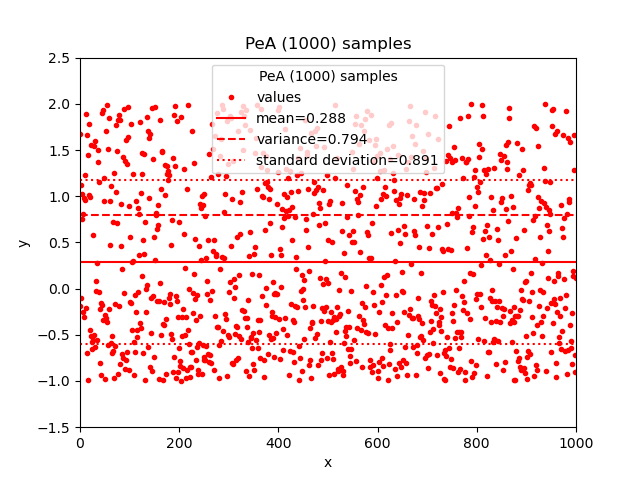

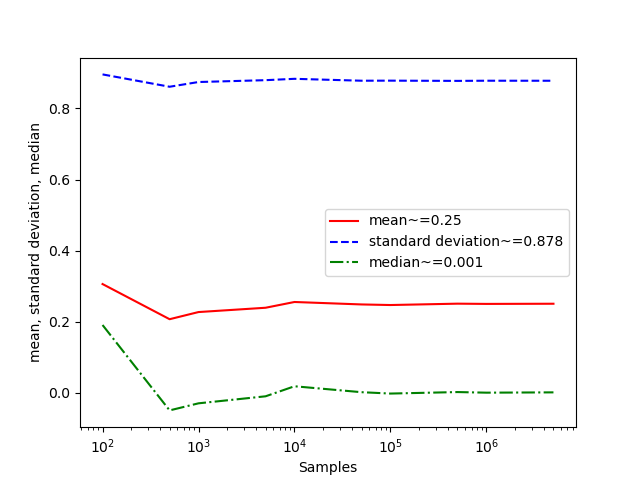

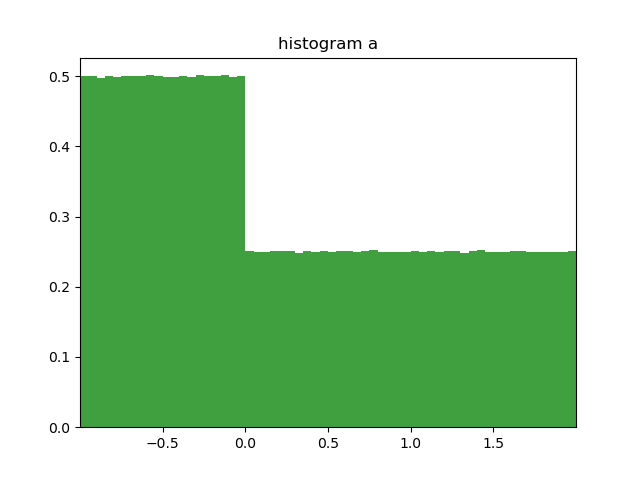

## Conclusions for a:
 Mean tends towards: 0.3
 Standard deviation tends towards: 0.9
 Median tends towards: 0.0


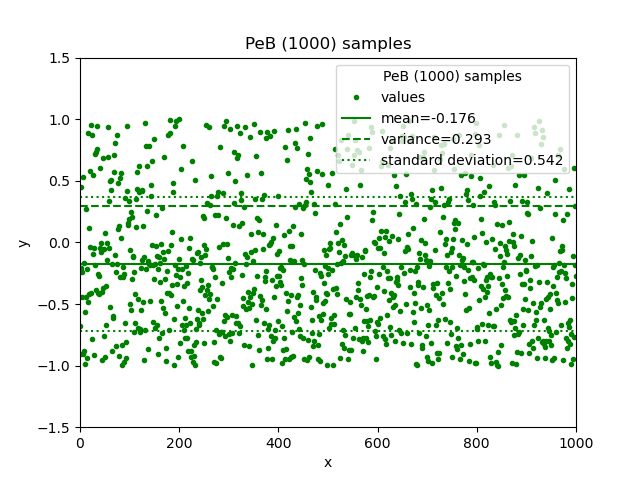

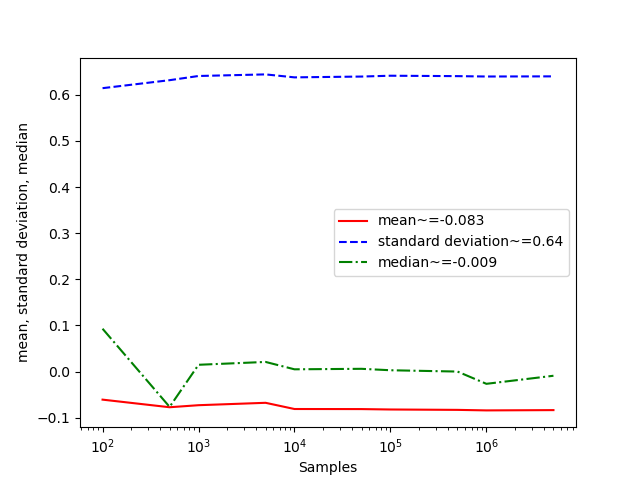

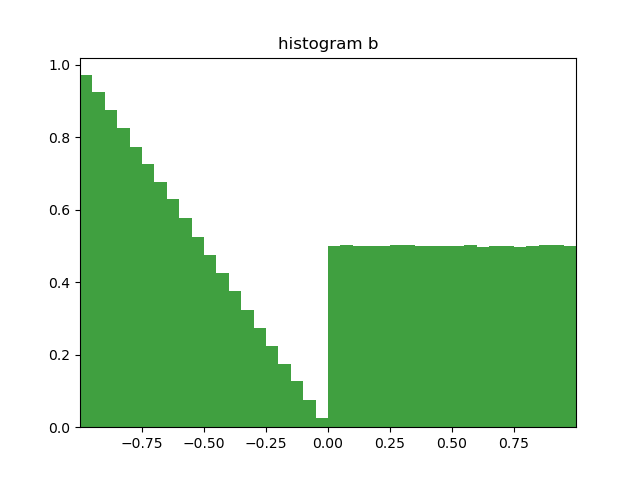

## Conclusions for b:
 Mean tends towards: -0.1
 Standard deviation tends towards: 0.6
 Median tends towards: -0.0


In [5]:
import sys
epsilon = sys.float_info.epsilon

nsamp = 1000

def GenSamplesF(n, f, mn, mx):
    samples = []
    while len(samples) < n:
        #p = ((i/n) * (mx-mn))+mn
        p = np.random.rand() * (mx-mn) + mn
        if np.random.rand() <= f(p):
            samples.append(p)
    return samples


# noinspection PyUnusedLocal
def EvaluateFunctionTendencies(f, mn, mx, stages, name):
    fig = plt.figure()
    plt.xlabel("Samples")
    plt.ylabel("mean, standard deviation, median")
    plt.xscale('log')
    resultsmean = []
    resultsdev = []
    resultsmedian = []
    seqs = []
    for stage in stages:
        seq = GenSamplesF(stage, f, mn, mx)
        resultsmean.append(np.mean(seq))
        resultsdev.append(math.sqrt(np.var(seq)))
        resultsmedian.append(np.median(seq))
        seqs.append(seq)
    mean = round(resultsmean[-1], 3);
    dev = round(resultsdev[-1], 3)
    median = round(resultsmedian[-1], 3)
    plt.plot(stages, resultsmean, "r-", label="mean~=" + str(mean))
    plt.plot(stages, resultsdev, "b--", label="standard deviation~=" + str(dev))
    plt.plot(stages, resultsmedian, "g-.", label="median~=" + str(median))
    #plt.axhline(2, color = 'k', linestyle = "--", label="y=2.0", alpha=0.5)
    plt.legend()
    plt.show()

    seq = seqs[-1]
    fig = plt.figure()
    plt.title("histogram " + name)
    plt.axis((min(seq), max(seq), None, None))
    n, bins, patches = plt.hist(seq, bins=np.arange(min(seq), max(seq) + 0.05, 0.05), density=True, facecolor='g', alpha=0.75, label="D")
    #plt.legend()
    plt.show()
    
    mean = round(resultsmean[-1], 1);
    dev = round(resultsdev[-1], 1)
    median = round(resultsmedian[-1], 1)
    
    conclusions = Markdown(f"## Conclusions for {name}:\n Mean tends towards: {mean}\n Standard deviation tends towards: {dev}\n Median tends towards: {median}\n")
    display(conclusions)
    return mean, dev, median

stages = [100, 500, 1000, 5000, 10000, 50000, 100000, 500000, 1000000, 5000000]

PeA = lambda e: 0.5 if (-1 < e < 0) else 0.25 if (0 <= e < 2) else 0

mnA = -1+epsilon
mxA = 2-epsilon
seqA = GenSamplesF(nsamp, PeA, mnA, mxA)
DrawSequenceMeanVariance(seqA, "PeA (" + str(nsamp) + ") samples"  , "r", -1.5, 2.5)

meanA, devA, medianA = EvaluateFunctionTendencies(PeA, mnA, mxA, stages, "a")


PeB = lambda e: -e if (-1 < e < 0) else 0.5 if (0 <= e < 1) else 0

mnB = -1+epsilon
mxB = 1-epsilon
seqB = GenSamplesF(nsamp, PeA, mnB, mxB)
DrawSequenceMeanVariance(seqB, "PeB (" + str(nsamp) + ") samples", "g", -1.5, 1.5)

meanB, devB, medianB = EvaluateFunctionTendencies(PeB, mnB, mxB, stages, "b")


## Notes:

# Exercise 6

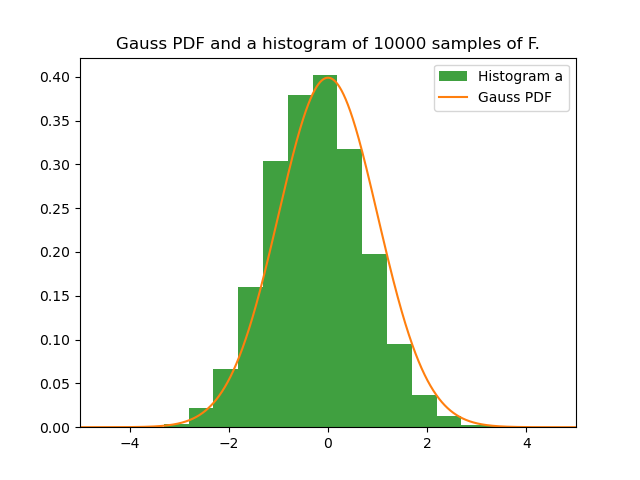

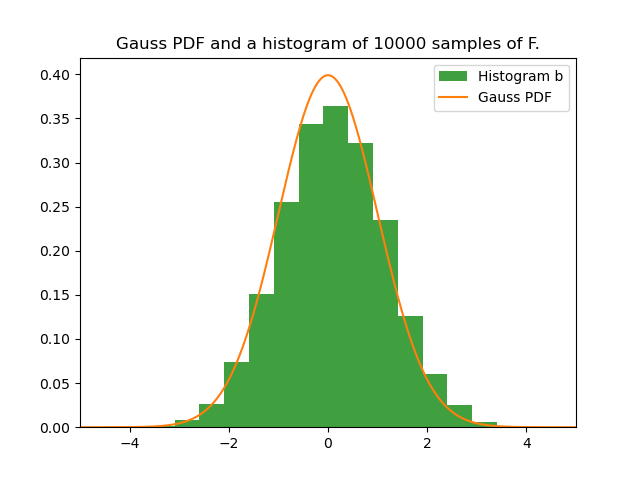

In [6]:
nsamples = 10000

gauss = lambda x, a, b: (1/math.sqrt(2*math.pi*b)) * math.exp(-(x - a)**2 / 2*b)
dist, points = ComputeDistribution(nsamples, -5, 5, gauss, 0, 1) 

def F6(f, mn, mx, mean, var):
    samples = GenSamplesF(16, f, mn, mx)
    l = [(x - mean)/math.sqrt(var) for x in samples]
    #print(mean, var)
    #print(l)
    return 0.25 * sum(l)
F6n = lambda n, f, mn, mx, mean, var: [F6(f, mn, mx, mean, var) for i in range(0, n)]


seqPA = F6n(nsamples, PeA, mnA, mxA, meanA, devA**2)
HistogramCompare(seqPA, 0.5, points, dist, "Histogram a", "Gauss PDF", f"Gauss PDF and a histogram of {len(seqPA)} samples of F."\
     , axis = (-5, 5, None, None))

seqPB = F6n(nsamples, PeB, mnB, mxB, meanB, devB**2)
HistogramCompare(seqPB, 0.5, points, dist, "Histogram b", "Gauss PDF", f"Gauss PDF and a histogram of {len(seqPB)} samples of F."\
     , axis = (-5, 5, None, None))




## Notes:

# Exercise 7

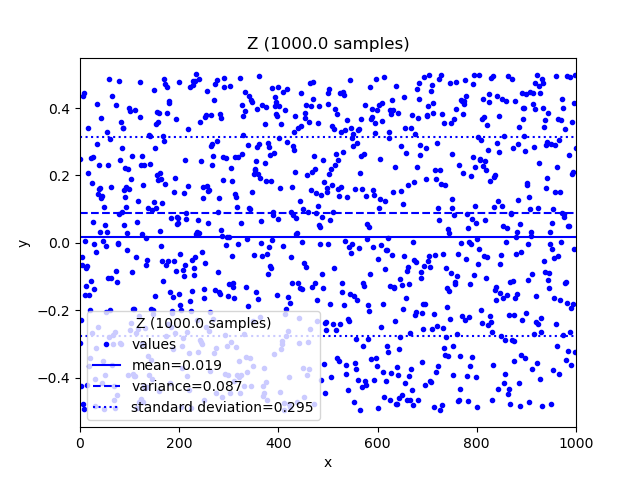

/tmp/ipykernel_174190/1608187371.py:14: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig = plt.figure()


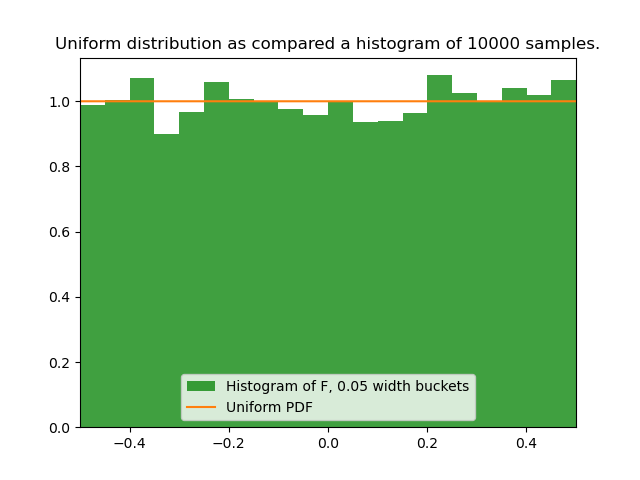

In [7]:
nsamples = 10000
def FZ():
    x = (np.random.rand()*(99-epsilon)+(1+epsilon))
    return x - round(x)
FZn = lambda n: [FZ() for i in range(0, n)]

uniform = lambda x, a, b: 1/(b-a)
dist, points = ComputeDistribution(nsamples, -0.5, 0.5, uniform, -0.5, 0.5)

seq = FZn(nsamples)
DrawSequenceMeanVariance(seq[::10], f"Z ({nsamples/10} samples)", 'b', None, None)
HistogramCompare(seq, 0.05, points, dist, "Histogram of F, 0.05 width buckets", "Uniform PDF", f"Uniform distribution as compared a histogram of {nsamples} samples.")

## Notes: 
The resulting distribution $Z$ is in effect a uniform distribution constrained to $Z \subset (-0.5, 0.5]$ or $Z \subset [-0.5, 0.5)$ depending on the rounding method used.

# Exercise 8

$\lim{x\to\infty}$ ($\frac{1}{2}+\frac{1}{\pi}\arctan(x)$) = 1

$\lim{x\to-\infty}$ ($\frac{1}{2}+\frac{1}{\pi}\arctan(x)$) = 0

$F_{X}(x)$ = $\frac{1}{2}+\frac{1}{\pi}\arctan(x)$

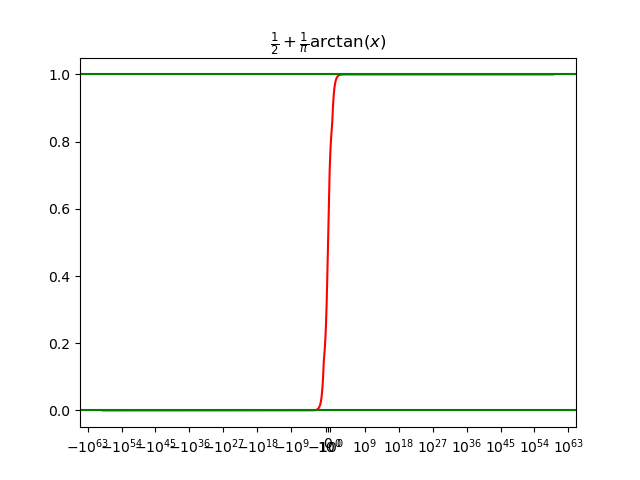

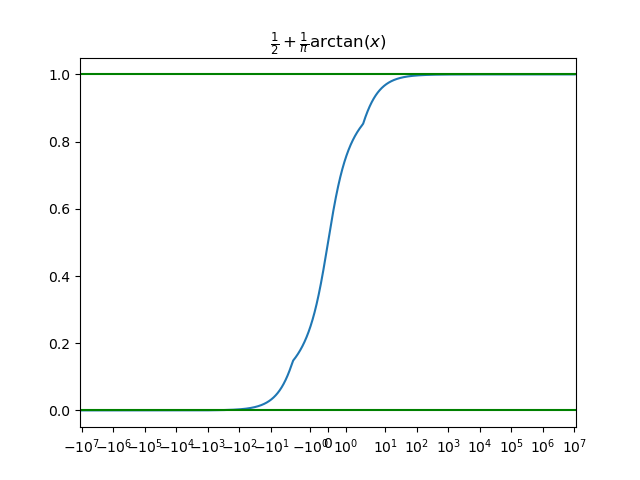

$0 \leq F_{X}(x) \le 1$

$F_{X}(-\infty) = 0$, $Fx(\infty)=1$

if $x_{1} < x_{2}$ then $P(x_{1} \lt X \le x_{2}) = F_{X}(x_{2}) - F_{X}(x_{1}) \ge 0$

Function is a valid CDF

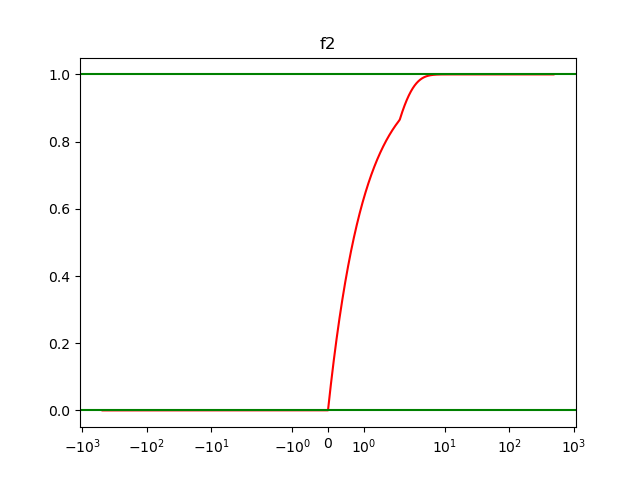

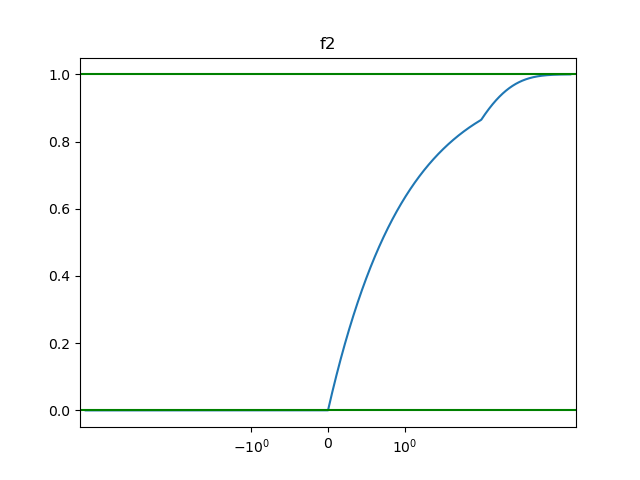

$0 \leq F_{X}(x) \le 1$

$F_{X}(-\infty) = 0$, $Fx(\infty)=1$

if $x_{1} < x_{2}$ then $P(x_{1} \lt X \le x_{2}) = F_{X}(x_{2}) - F_{X}(x_{1}) \ge 0$

Function is a valid CDF

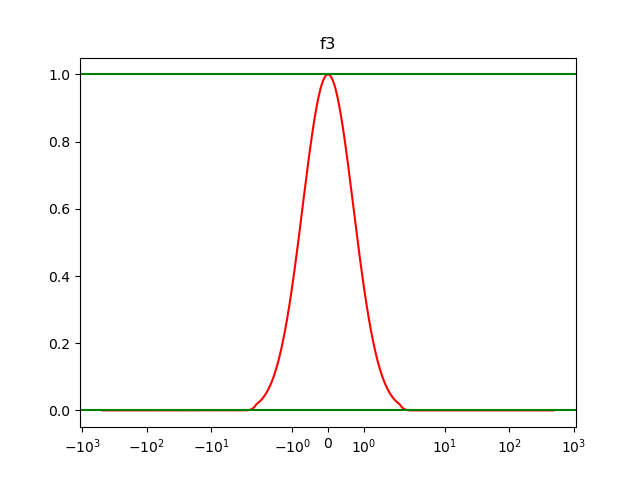

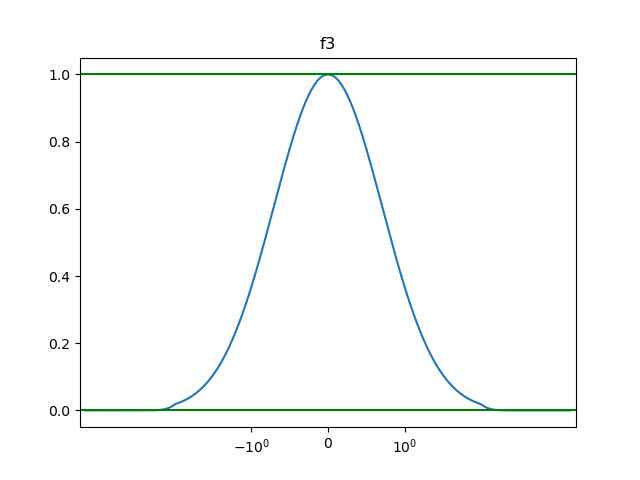

if $x_{1} < x_{2}$ then $P(x_{1} \lt X \le x_{2}) = F_{X}(x_{2}) - F_{X}(x_{1}) \ge 0$

Function does not rise for all values of $x$

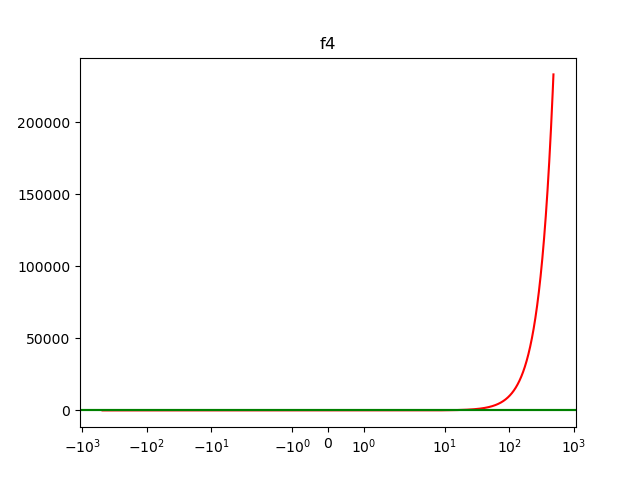

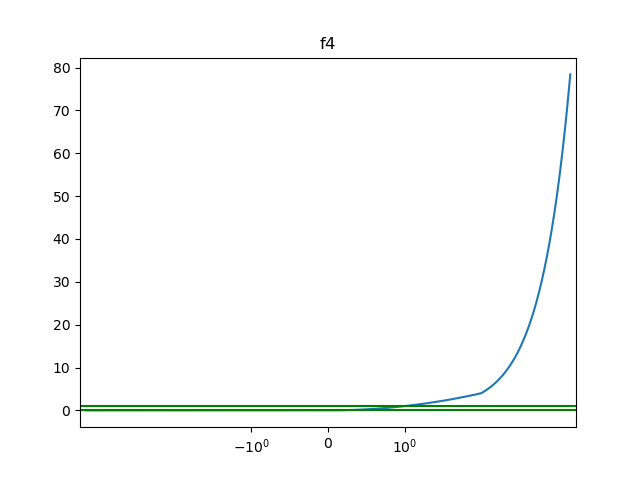

$0 \leq F_{X}(x) \le 1$

Does not fit range, max=233323.498858039 & min=0.0

In [8]:
nsamples = 100000
def GenSamplePointsPow(n, fact):
    ret = []
    n -= 1
    v = 10 ** -6
    while n > 0:
        ret.append(v)
        v = v * fact
        n -= 2
    return [-n for n in ret[::-1]] + [0] + ret
GenFromPointsF = lambda points, f: [f(n) for n in points]
def TestF(samplepoints, f, title, interestmin, interestmax):
    seq = GenFromPointsF(samplepoints, f)
    # noinspection PyUnusedLocal
    fig = plt.figure()
    plt.title(title)
    plt.plot(samplepoints, seq, "r")
    plt.xscale("symlog")
    plt.axhline(1, color="g")
    plt.axhline(0, color="g")
    plt.show()

    rising = True
    inrange = True
    pn = seq[0]
    for n in seq:
        if n < 0 or n > 1:
            inrange = False
        if n < pn:
            rising = False
                
        pn = n
    fig = plt.figure()
    mn = round(interestmin*len(seq))
    mx = round(interestmax*len(seq))
    plt.plot(samplepoints[mn:mx], seq[mn:mx])
    plt.axhline(1, color="g")
    plt.axhline(0, color="g")
    plt.xscale("symlog")
    plt.title(title)
    plt.show()

    pred_lim = Markdown("$F_{X}(-\\infty) = 0$, $Fx(\\infty)=1$")
    pred_inrange = Markdown("$0 \\leq F_{X}(x) \\le 1$")
    pred_rise = Markdown("if $x_{1} < x_{2}$ then $P(x_{1} \\lt X \\le x_{2}) = F_{X}(x_{2}) - F_{X}(x_{1}) \\ge 0$")
    
    if not inrange:
        display(pred_inrange)
        display(Markdown(f"Does not fit range, max={max(seq)} & min={min(seq)}"))
    elif not rising:
        display(pred_rise)
        display(Markdown("Function does not rise for all values of $x$"))
    else:
        display(pred_inrange)
        display(pred_lim)
        display(pred_rise)
        display(Markdown("Function is a valid CDF"))
    

f1 = lambda x: 0.5 + (1/math.pi)*math.atan(x)
f2 = lambda x: (1-math.e**-x) * (1 if x >= 0 else 0)
f3 = lambda x: math.e**-(x**2)
f4 = lambda x: x**2 * (1 if x >= 0 else 0)

samplepoints0 = GenSamplePointsPow(nsamples, 1.003)
samplepoints1 = GenSamplePointsPow(nsamples, 1.0004)

f1eq = "$\\frac{1}{2}+\\frac{1}{\\pi}\\arctan(x)$"
display(Markdown("$\\lim{x\\to\\infty}$" + f" ({f1eq}) = 1"))
display(Markdown("$\\lim{x\\to-\\infty}$" + f" ({f1eq}) = 0"))
display(Markdown("$F_{X}(x)$ = " + f"{f1eq}"))
TestF(samplepoints0, f1, f1eq, 0.4, 0.6)


f2eq = "$$"        
TestF(samplepoints1, f2, "f2", 0.1, 0.9)
        
TestF(samplepoints1, f3, "f3", 0.1, 0.9)
        
TestF(samplepoints1, f4, "f4", 0.1, 0.9)


## Notes:


# Exercise 9

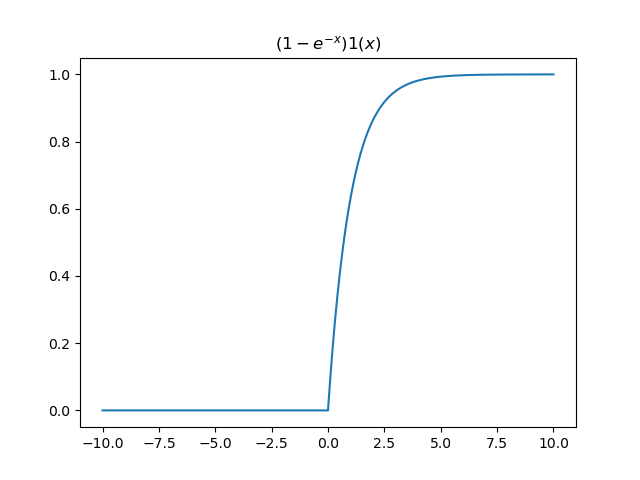

In [25]:
f = lambda x: (1-math.e**-x)*(1 if x >= 0 else 0)
span = np.linspace(-10, 10, 10000)
seq = [f(x) for x in span]
fig = plt.figure()
plt.title("$(1-e^{-x})1(x)$")
plt.plot(span, seq)
plt.show()

## Notes:

$F_{x}(x) = (1-e^{-x})1(x)$

$P(X\lt5) = F_{x}(5) = 1 - e^{-5}$

$P(X\gt5) = 1 - F_{x}(5) = e^{-5}$

$P(3 \lt X \lt 7) = F_{x}(7) - F_{x}(3) = -e^{-7} + e^{-5}$

$P(X \gt 5 \mid X \lt 7) = \frac{P(X > 5 \cap X < 7)}{P(X < 7)} = \frac{P(3 \lt X \lt 7)}{P(X < 7)} = \frac{F_{x}(7)- F_{x}(5)}{F_{x}(7)} = \frac{-e^{-7}+e^{-5}}{e^{-7}}$

# Exercise 10

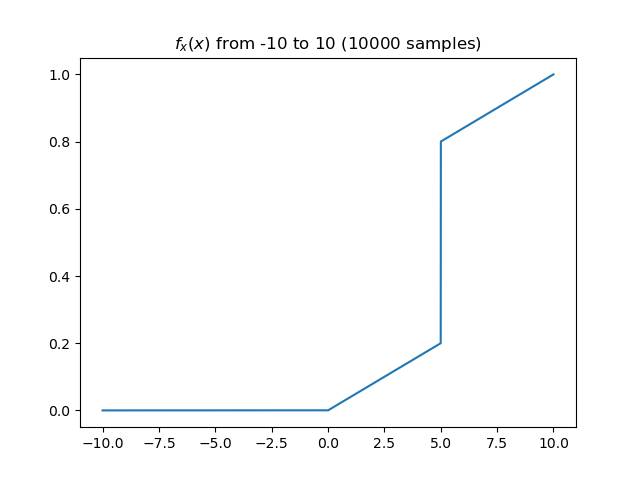

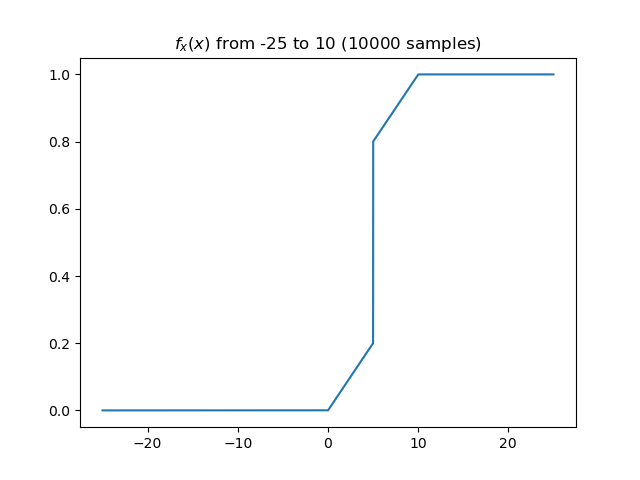

In [45]:
f = lambda x: 0 if x <= 0 else 0.04*x if x <= 5 else 0.6+0.04*x if x <= 10 else 1

ftext = "todo"


# noinspection PyUnusedLocal
def GenFigureFromCDF(n:int, mn:float, mx:float, f, title:str, mentionrange=True):
    span = np.linspace(mn, mx, n)
    seq = [f(x) for x in span]
    fig = plt.figure()
    if mentionrange:
        title += f" from {mn} to {10} ({n} samples)"
    plt.title(title)
    plt.plot(span, seq)
    plt.show()
    return span, seq

GenFigureFromCDF(10000, -10, 10, f, "$f_x(x)$")
GenFigureFromCDF(10000, -25, 25, f, "$f_x(x)$")

None

In [15]:
print(f(5))
print(1 - f(5))
print(f(7) - f(3))
print((f(7) - f(5))/f(7))

0.2
0.8
0.76
0.7727272727272727


## Notes:

$F_{x}(x) = \begin{cases}
    \begin{matrix}
        0 & x \le 10 \\
        0.04x & 0 \lt x \le 5 \\
        0.6 + 0.04x & 5 \lt x \le 10 \\
        1 & x \gt 10
    \end{matrix}
\end{cases}$

$P(X\lt5) = F_{x}(5) = 0.2$

$P(X\gt5) = 1 - F_{x}(5) = 0.8$

$P(3 \lt X \lt 7) = F_{x}(7) - F_{x}(3) = (0.6 + 0.28) - 0.12 = 0.76$

$P(X \gt 5 \mid X \lt 7) = \frac{F_{x}(7)- F_{x}(5)}{F_{x}(7)} \approx 0.7(72...) $

# Exercise 11

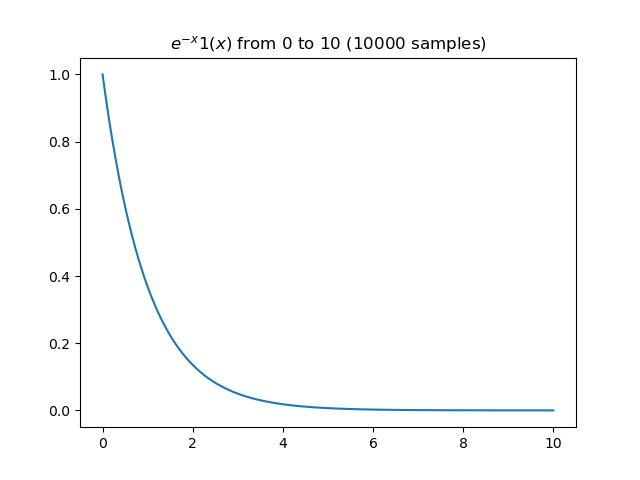

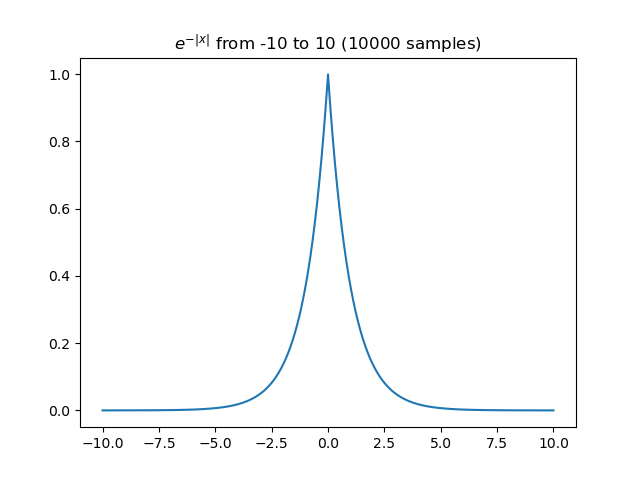

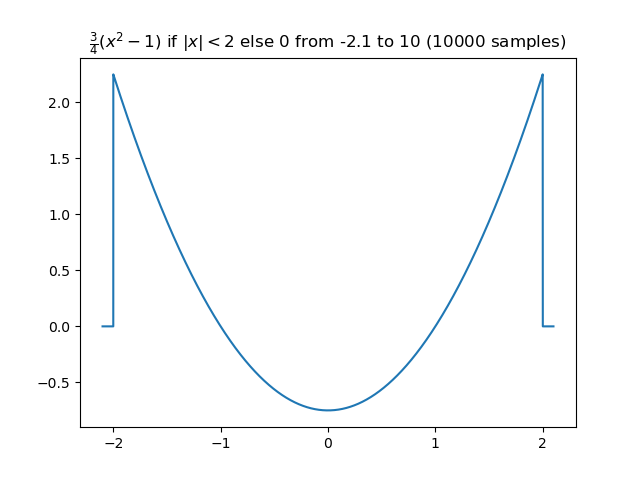

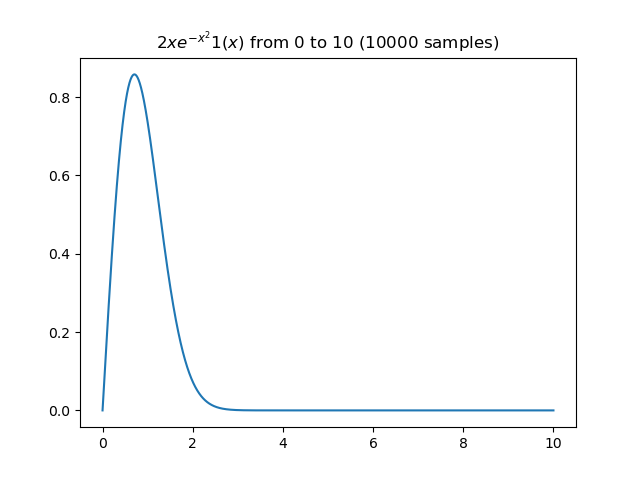

In [47]:
f0 = lambda x: (e**-x) * (0 if x < 0 else 1)
f1 = lambda x: e**-(abs(x))
f2 = lambda x: (0.75*(x**2 - 1)) if abs(x) < 2 else 0
f3 = lambda x: 2*x*e**(-x**2) if x >= 0 else 0

GenFigureFromCDF(10000, 0, 10, f0, "$e^{-x}1(x)$")
GenFigureFromCDF(10000, -10, 10, f1, "$e^{-|x|}$")
GenFigureFromCDF(10000, -2.1, 2.1, f2, "$\\frac{3}{4}(x^2 - 1)$ if $|x| < 2$ else $0$")
GenFigureFromCDF(10000, 0, 10, f3, "$2xe^{-x^2}1(x)$")


None